In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
import os

files = os.listdir("../data/raw")

print(files[:10])

['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'yfinance_data.zip']


In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [7]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 358.4 MB


In [9]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [10]:
df["headline_length"] = df["headline"].astype(str).apply(len)

df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

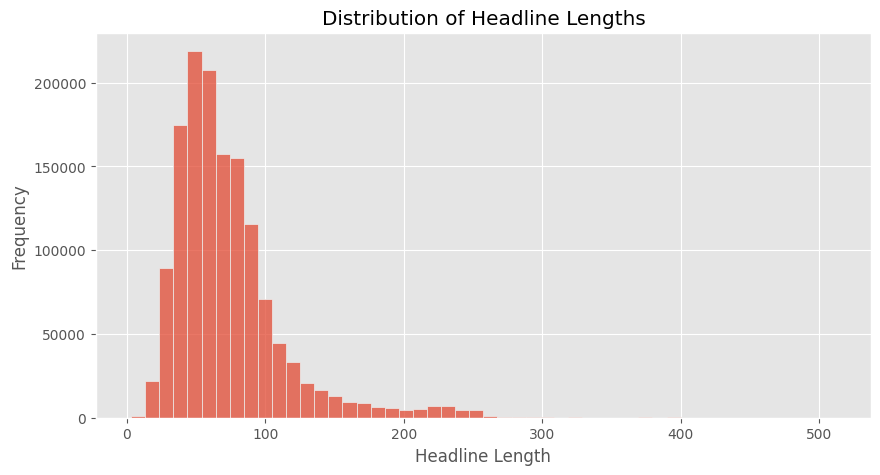

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df["headline_length"], bins=50)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

In [12]:
top_publishers = df["publisher"].value_counts().head(10)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

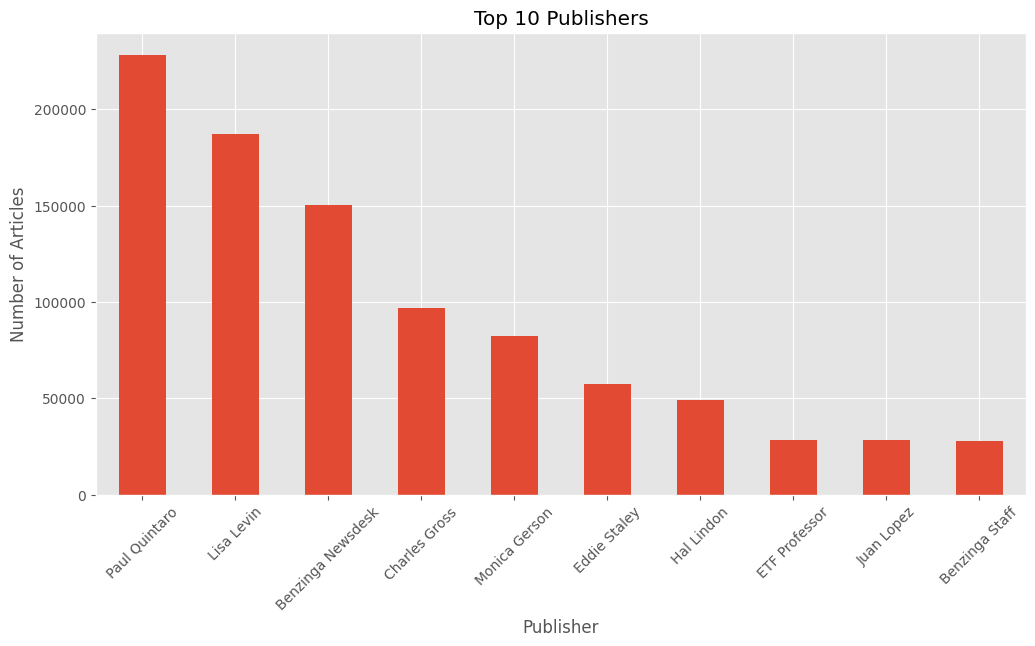

In [13]:
plt.figure(figsize=(12,6))

top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

In [14]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract date only
df["only_date"] = df["date"].dt.date

df[["date", "only_date"]].head()

,date,only_date
0,2020-06-05 10:30:54-04:00,2020-06-05
1,2020-06-03 10:45:20-04:00,2020-06-03
2,2020-05-26 04:30:07-04:00,2020-05-26
3,2020-05-22 12:45:06-04:00,2020-05-22
4,2020-05-22 11:38:59-04:00,2020-05-22


In [15]:
daily_articles = df.groupby("only_date").size()

daily_articles.head()

only_date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

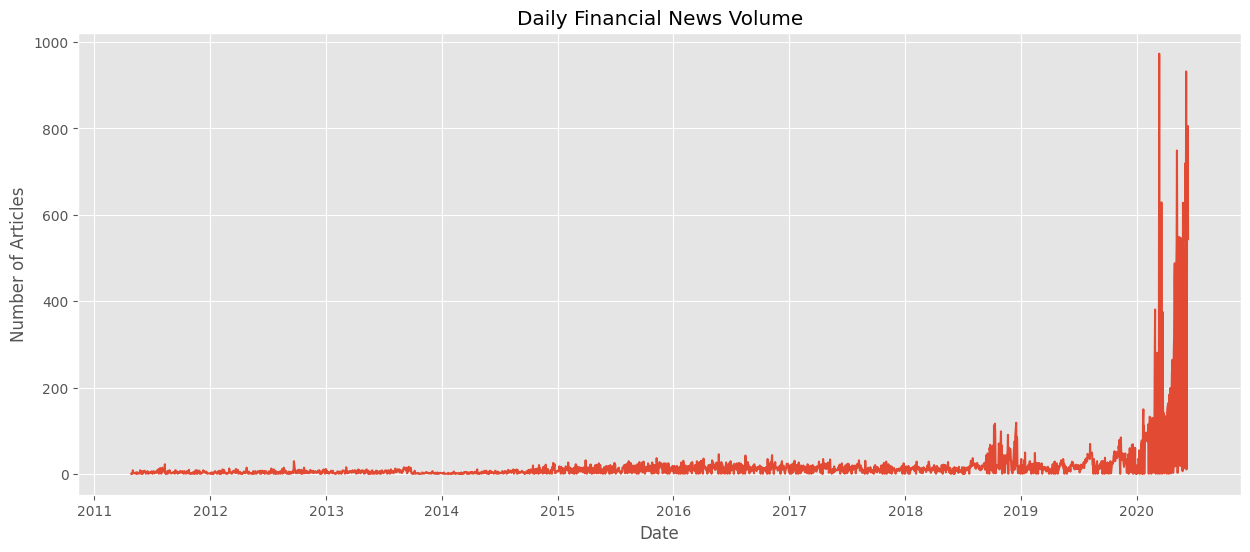

In [16]:
plt.figure(figsize=(15,6))

daily_articles.plot()

plt.title("Daily Financial News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [17]:
df["hour"] = df["date"].dt.hour

hour_counts = df["hour"].value_counts().sort_index()

hour_counts

hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

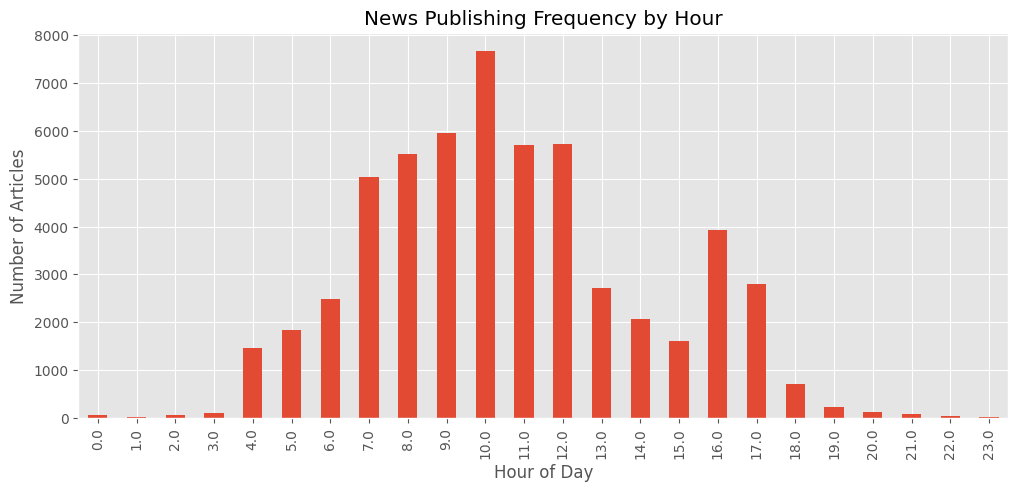

In [18]:
plt.figure(figsize=(12,5))

hour_counts.plot(kind="bar")

plt.title("News Publishing Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

In [20]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["headline"].astype(str))

keywords = vectorizer.get_feature_names_out()

keywords

array(['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps',
       'est', 'market', 'mid', 'price', 'pt', 'raises', 'reports',
       'sales', 'shares', 'stocks', 'trading', 'update', 'vs', 'week'],
      dtype=object)

In [21]:
word_counts = X.toarray().sum(axis=0)

keyword_df = pd.DataFrame({
    "Keyword": keywords,
    "Count": word_counts
})

keyword_df = keyword_df.sort_values(
    by="Count",
    ascending=False
)

keyword_df

,Keyword,Count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


In [22]:
word_counts = X.toarray().sum(axis=0)

keyword_df = pd.DataFrame({
    "Keyword": keywords,
    "Count": word_counts
})

keyword_df = keyword_df.sort_values(
    by="Count",
    ascending=False
)

keyword_df

,Keyword,Count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


In [23]:
df["publisher"] = df["publisher"].astype(str)

domains = df["publisher"].str.extract(r'@(.+)')

domains.value_counts().head(10)

0                     
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

# Key Insights

- Financial news volume shows noticeable spikes during major market periods.
- Certain publishers dominate financial reporting activity.
- Most articles are published during active market trading hours.
- Frequently occurring keywords suggest strong focus on stock performance, earnings, and analyst ratings.
- The dataset contains large-scale financial sentiment information suitable for predictive stock analysis.